# 分类算法（Classification Algorithms）

## 一、数据集探索

> 本节演示如何加载 sklearn 内置的 Iris 鸢尾花、20 Newsgroups 文本、California Housing 回归三个数据集，了解数据集的基本结构与信息。

In [1]:
# 加载 sklearn 内置鸢尾花（Iris）数据集，转为 DataFrame 便于观察与后续建模
from sklearn.datasets import load_iris  # 返回 Bunch 对象，含 data/target/feature_names/target_names 等属性
import pandas as pd  # 提供 DataFrame 表格结构，便于查看特征矩阵
import matplotlib.pyplot as plt  # 绘图库，本单元后续 cell 中绘制散点图

iris = load_iris()  # 调用后立即返回 Bunch；iris.data 形状 (150,4)，iris.target 形状 (150,) 含 0/1/2

print("数据集描述：")  # 打印标题
print(iris.DESCR)  # 字符串，含样本数、特征说明、类别分布等文档

# 将特征矩阵 iris.data 与列名 iris.feature_names 组合为 DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)  # 返回 DataFrame，150行4列
iris_df['target'] = iris.target  # 新增整数标签列；值为 0/1/2 对应三个花种
iris_df['target_names'] = [iris.target_names[i] for i in iris.target]  # 列表推导式；将整数映射为可读花种名

print("\n数据集基本信息：")  # 打印标题
print(f"样本数量: {len(iris_df)}")  # len(DataFrame) 返回行数，应为 150
print(f"特征数量: {iris.feature_names}")  # list[str]，4 个特征名
print(f"目标类别: {list(iris.target_names)}")  # 转为 list 打印三种花名

print(f"target: {iris.target}")  # 打印全部 150 个整数标签
print("\n数据集：")  # 打印标题
iris_df  # Jupyter 最后一行自动渲染为 HTML 表格


数据集描述：
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 class

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


### 1.1 Iris 数据集特征散点图可视化

> 绘制鸢尾花数据集各特征的两两散点图，直观观察不同品种（setosa / versicolor / virginica）在特征空间中的分布规律与线性可分程度。

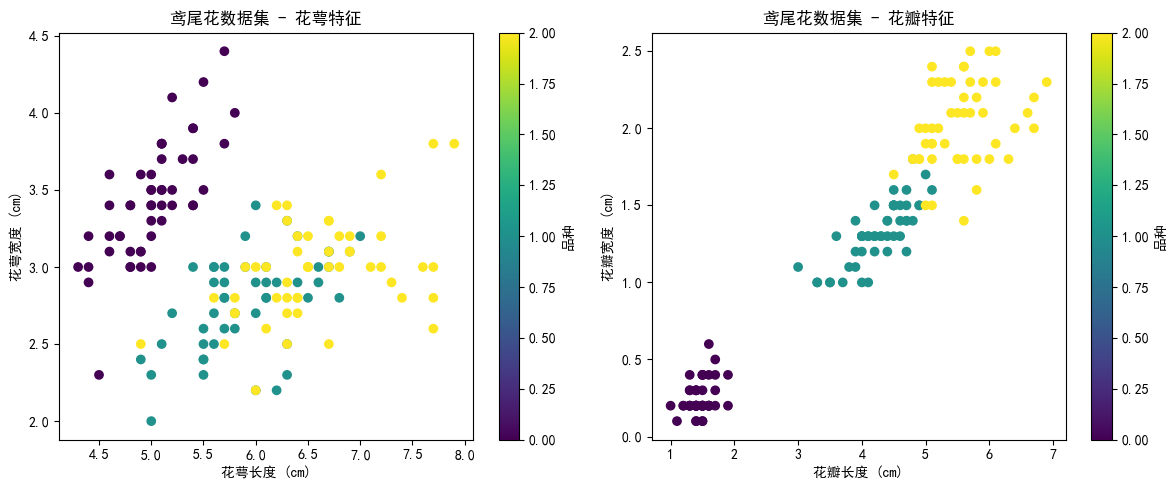

In [2]:
# 绘制鸢尾花散点图：观察不同品种在两个特征平面上的分布规律

import matplotlib.font_manager as fm  # 字体管理模块，用于配置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置全局无衬线字体为黑体，使中文正常显示
plt.rcParams['axes.unicode_minus'] = False  # 禁用 unicode 负号，避免负数符号显示为方块

plt.figure(figsize=(12, 5))  # 创建宽 12 英寸、高 5 英寸的图窗

plt.subplot(1, 2, 1)  # 在 1×2 网格中激活第 1 个子图（花萼特征）
# c=iris_df['target'] 用类别整数上色；cmap='viridis' 为蓝绿黄渐变色图
plt.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], c=iris_df['target'], cmap='viridis')  # 画散点图；每个点代表一株鸢尾花
plt.xlabel('花萼长度 (cm)')  # x 轴标签
plt.ylabel('花萼宽度 (cm)')  # y 轴标签
plt.title('鸢尾花数据集 - 花萼特征')  # 子图标题
plt.colorbar(label='品种')  # 添加颜色条；数值 0/1/2 对应三个花种

plt.subplot(1, 2, 2)  # 激活第 2 个子图（花瓣特征）
plt.scatter(iris_df['petal length (cm)'], iris_df['petal width (cm)'], c=iris_df['target'], cmap='viridis')  # 花瓣散点图；类别分离更明显
plt.xlabel('花瓣长度 (cm)')  # x 轴标签
plt.ylabel('花瓣宽度 (cm)')  # y 轴标签
plt.title('鸢尾花数据集 - 花瓣特征')  # 子图标题
plt.colorbar(label='品种')  # 颜色条

plt.tight_layout()  # 自动调整子图间距，防止标签重叠
plt.show()  # 渲染并显示图像


### 1.2 20 Newsgroups 文本分类数据集加载

> 加载 20 Newsgroups 文本数据集，共 20 个主题的新闻邮件，了解 （文本列表）、（类别 id）、（类别名）等字段，为文本分类任务做准备。

In [3]:
# 加载 20 Newsgroups 文本分类数据集（含 20 个新闻组的邮件文本）
from sklearn.datasets import fetch_20newsgroups  # 返回 Bunch；data=文本列表，target=类别id数组

data_home = './data'  # 数据缓存目录；首次运行会从网络下载并保存到此处

# subset='all' 合并 train+test 子集；shuffle=True 打乱顺序；random_state 固定随机种子保证可复现
newsgroups = fetch_20newsgroups(
    data_home=data_home,   # str | PathLike：本地缓存目录；若该目录下已有 20news-bydate_py3.pkz 则直接读取，不会重复下载
    subset='all',          # str：加载的子集，'train'=训练集 / 'test'=测试集 / 'all'=合并全部，共约 18846 条
    shuffle=True,          # bool：是否在加载后随机打乱样本顺序，True 可避免类别聚集影响后续切分
    random_state=42,       # int | None：随机种子，固定后每次运行打乱结果相同，保证实验可复现
)
# 返回值 newsgroups 类型为 sklearn.utils.Bunch（类字典对象），主要字段：
#   .data         list[str]       ：每个元素为一封新闻邮件的原始文本
#   .target       np.ndarray[int] ：每条样本对应的类别 id，范围 0~19
#   .target_names list[str]       ：长度为 20 的类别名称列表，target[i] 即对应 target_names 中的索引
#   .filenames    np.ndarray[str] ：每条样本在本地缓存中的文件路径

print("20类新闻数据集基本信息：")  # 打印标题
print(f"样本数量: {len(newsgroups.data)}")  # 文本篇数（整数）
print(f"目标类别数量: {len(newsgroups.target_names)}")  # 应为 20
print(f"目标类别: {newsgroups.target_names}")  # list[str]，20 个新闻组名称

print("\n前5个样本的类别:")  # 打印标题
for i in range(5):  # 遍历前 5 条样本；i 为整数索引
    print(f"样本 {i+1}: 类别 {newsgroups.target[i]} - {newsgroups.target_names[newsgroups.target[i]]}")  # 打印类别 id 和对应类别名

print(f"target的最大值: {newsgroups.target.max()}")  # 类别 id 上界，应为 19（共 20 个类）
print(f"target的最小值: {newsgroups.target.min()}")  # 类别 id 下界，应为 0

print("\n第一个样本的内容:")  # 打印标题
print(newsgroups.data[0][:500] + "...")  # 每篇为长字符串，截取前 500 字符预览

print("\n第二个样本的内容:")  # 打印标题
print(newsgroups.data[1][:500] + "...")  # 截取前 500 字符


20类新闻数据集基本信息：
样本数量: 18846
目标类别数量: 20
目标类别: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

前5个样本的类别:
样本 1: 类别 10 - rec.sport.hockey
样本 2: 类别 3 - comp.sys.ibm.pc.hardware
样本 3: 类别 17 - talk.politics.mideast
样本 4: 类别 3 - comp.sys.ibm.pc.hardware
样本 5: 类别 4 - comp.sys.mac.hardware
target的最大值: 19
target的最小值: 0

第一个样本的内容:
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actu

### 1.3 California Housing 回归数据集加载

> 加载加利福尼亚州房价数据集（California Housing），了解其 8 个特征（人口、收入、房龄等）和回归目标（房价中位数），初步认识回归任务的数据结构。

In [ ]:
# 加利福尼亚房价数据集：用于了解回归任务数据结构（8个特征 → 房价中位数）
from random import shuffle
from pandas.core.common import random_state
from pandas.io.formats.style import Subset
from sklearn.datasets import fetch_california_housing  # 返回 Bunch；data形状(20640,8)，target为房价中位数
import pandas as pd  # 用于构造 DataFrame 便于查看
import matplotlib.pyplot as plt  # 绘图库
import numpy as np  # 数值计算库
data_home=r"./data"
# fetch_california_housing 常用参数说明：
#   data_home: str 或 PathLike，可选，指定数据集本地缓存目录，默认在 ~/scikit_learn_data
#   download_if_missing: bool, 可选，默认True，若本地无数据则会自动下载
#   return_X_y: bool, 可选，若为True，则直接返回(X, y)元组，不返回Bunch对象
california = fetch_california_housing(data_home=data_home)  # 加载加利福尼亚州房价数据集，data形状(20640,8)，target形状(20640,)
# 返回值 california 类型为 sklearn.utils.Bunch（类字典对象），主要包含：
#   .data: ndarray, shape (20640, 8)，每行一个样本（8个特征）
#   .target: ndarray, shape (20640,)，每个样本对应房价中位数（单位：10万美元）
#   .feature_names: list[str]，8 个特征名称
#   .DESCR: str，数据集描述文本

california_df = pd.DataFrame(california.data, columns=california.feature_names)  # 将特征矩阵转为DataFrame；行=样本，列=特征
california_df['target'] = california.target  # 新增房价中位数列（单位：10万美元）；连续值标签

print("加利福尼亚房价数据集基本信息：")  # 打印标题
print(f"样本数量: {california.data.shape[0]}")  # shape[0] 为行数，即样本数
print(f"特征数量: {california.data.shape[1]}")  # shape[1] 为列数，即特征数，应为 8
print(f"特征名称: {california.feature_names}")  # list[str]，8 个特征的名称
print(california.DESCR)  # 字符串，含各特征的物理含义和统计说明

print("\n数据集的前5行:")  # 打印标题
california_df.head()  # head() 默认返回前 5 行 DataFrame；Jupyter 中自动渲染为表格


加利福尼亚房价数据集基本信息：
样本数量: 20640
特征数量: 8
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hund

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 1.4 划分训练集和测试集

> 使用  将数据集按比例划分为训练集与测试集， 参数可保证类别比例一致，避免类别不均衡问题。

In [ ]:
# train_test_split：将数据集划分为训练集和测试集，stratify 保持各类比例一致
from sklearn.model_selection import train_test_split  # 返回 4 个数组：X_train, X_test, y_train, y_test
from sklearn.datasets import load_iris  # 加载鸢尾花数据集
import numpy as np  # 用于统计各类别样本数

iris = load_iris()  # 加载鸢尾花数据集；返回 Bunch 对象
X = iris.data  # 特征矩阵；ndarray，形状 (150, 4)
y = iris.target  # 标签向量；ndarray，形状 (150,)，值为 0/1/2

# test_size=0.2 表示 20% 数据用于测试集，80% 用于训练集
# stratify=y 参数保证训练集和测试集中的类别（即y的分布）与原始数据一致，避免某一类别在某个子集中缺失或数据不均衡
# random_state=42 设置随机种子，使得每次运行都得到相同的划分结果（实验可复现）
X_train, X_test, y_train, y_test = train_test_split(
    X,                   # 特征矩阵
    y,                   # 标签向量
    test_size=0.2,       # 测试集占20%
    random_state=42,     # 固定随机数种子
    stratify=y           # 分层抽样，保证类别比例一致
)  # train_test_split 返回 4 个 ndarray 分别对应 训练特征、测试特征、训练标签、测试标签

print("鸢尾花数据集划分结果：")  # 打印标题
print(f"训练集样本数量: {X_train.shape[0]}")  # 应为 120（150×0.8）
print(f"测试集样本数量: {X_test.shape[0]}")  # 应为 30（150×0.2）
print(f"特征数量: {X_train.shape[1]}")  # 应为 4
print(f"训练集中各类别样本数量:")  # 打印标题
for i, name in enumerate(iris.target_names):  # i 为类别索引(int)，name 为类别名(str)
    print(f"  {name}: {np.sum(y_train == i)}")  # y_train==i 生成布尔数组，sum 统计 True 的个数
print(f"测试集中各类别样本数量:")  # 打印标题
for i, name in enumerate(iris.target_names):  # 同上，遍历测试集类别分布
    print(f"  {name}: {np.sum(y_test == i)}")  # 应与训练集比例一致（stratify 的效果）


鸢尾花数据集划分结果：
训练集样本数量: 120
测试集样本数量: 30
特征数量: 4
训练集中各类别样本数量:
  setosa: 40
  versicolor: 40
  virginica: 40
测试集中各类别样本数量:
  setosa: 10
  versicolor: 10
  virginica: 10


## 二、KNN（K-近邻算法）

### 2.1 KNN 完整流程示例

> 以 Iris 数据集为例，完整演示 KNN 算法的标准化 → 划分 → 训练 → 预测 → 评估全流程，帮助理解 KNN 的基本使用范式。

In [6]:
# KNN 分类完整流程示例：标准化 → 划分 → 训练 → 预测 → 评估
from sklearn.datasets import load_iris  # 加载鸢尾花数据集
from sklearn.model_selection import train_test_split  # 数据集划分工具
from sklearn.preprocessing import StandardScaler  # 特征标准化，使各特征均值0方差1
from sklearn.neighbors import KNeighborsClassifier  # K 近邻分类器
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # 评估指标

iris = load_iris()  # 加载数据集
X, y = iris.data, iris.target  # X：(150,4) 特征矩阵；y：(150,) 标签向量

scaler = StandardScaler()  # 初始化标准化器
X_scaled = scaler.fit_transform(X)  # 在全量数据上 fit 并 transform；教学示例，实战应仅在训练集 fit

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)  # 按7:3划分

knn = KNeighborsClassifier(n_neighbors=5)  # K=5；默认欧氏距离；weights='uniform' 等权投票

knn.fit(X_train, y_train)  # KNN 无传统训练过程，此步骤仅将训练样本存入模型

y_pred = knn.predict(X_test)  # 对每个测试样本找 5 个最近邻并投票；返回 ndarray[int]，长度=测试集大小

print("准确率:", accuracy_score(y_test, y_pred))  # 正确预测数/总数；float，范围 [0,1]
print("\n分类报告:\n", classification_report(y_test, y_pred, target_names=iris.target_names))  # 含precision/recall/f1/support
print("\n混淆矩阵:\n", confusion_matrix(y_test, y_pred))  # ndarray；行=真实类别，列=预测类别


准确率: 1.0

分类报告:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


混淆矩阵:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


### 2.2 KNN 实战：Facebook 签到位置预测

> 使用真实的 Facebook 签到数据集，完整演示数据清洗、特征工程、KNN 建模、超参数调优的全流程。

In [7]:
# KNN 实战：Facebook 签到位置预测 —— 数据清洗、时间特征提取、标准化

import pandas as pd  # 用于读取 CSV 和数据处理
import numpy as np  # 数值计算
from sklearn.preprocessing import StandardScaler  # 特征标准化
from sklearn.neighbors import KNeighborsClassifier  # KNN 分类器
from sklearn.model_selection import train_test_split  # 数据集划分
from datetime import datetime  # 日期时间处理（本示例通过 pandas 处理，此处保留备用）

fb_train = pd.read_csv('./data/FBlocation/train.csv')  # 读取 CSV；含 row_id/x/y/accuracy/time/place_id 列

fb_train['time_formatted'] = pd.to_datetime(fb_train['time'], unit='m')  # Unix 时间戳（分钟）→ datetime64[ns]；unit='m' 指定时间单位为分钟，datetime64 是 numpy/pandas 内部用于高效存储和运算时间戳的数据类型，精确到纳秒（[ns]），用于后续方便提取时间特征

fb_train['weekday'] = fb_train['time_formatted'].dt.dayofweek  # 返回整数 0~6；0=周一，6=周日
fb_train['hour'] = fb_train['time_formatted'].dt.hour  # 返回整数 0~23；代表小时
fb_train['day'] = fb_train['time_formatted'].dt.day  # 返回整数 1~31；代表月中第几天

print("数据集基本信息：")  # 打印标题
print(f"样本数量: {fb_train.shape[0]}")  # shape[0] 为行数（样本数）
print(f"特征数量: {fb_train.shape[1]}")  # shape[1] 为列数（含新增时间特征）
print("\n数据集的前5行:")  # 打印标题
print(fb_train.head(5))  # 打印前 5 行；返回 DataFrame

print("\n检查缺失值:")  # 打印标题
print(fb_train.isnull().sum())  # 每列缺失个数；返回 Series，索引为列名，值为缺失数

# query 用字符串表达式过滤行；筛选地理位置在小方格内的签到点，缩小问题规模
filtered_fb_train = fb_train.query("x > 1.0 &  x < 1.25 & y > 2.5 & y < 2.75")  # 返回满足条件的子 DataFrame

print(f"筛选后的样本数量: {filtered_fb_train.shape[0]}")  # 筛选后的行数
print(f"筛选前的样本数量: {fb_train.shape[0]}")  # 原始行数
print(f"筛选比例: {filtered_fb_train.shape[0]/fb_train.shape[0]:.2%}")  # 保留比例；:.2% 格式化为百分比

place_counts = filtered_fb_train['place_id'].value_counts()  # 返回 Series；索引=place_id，值=出现次数，降序排列

valid_places = place_counts[place_counts > 3].index  # 布尔索引过滤；保留出现次数>3的地点 id；返回 Index

before_place_filter_count = filtered_fb_train.shape[0]  # 记录过滤前行数，用于计算剔除比例
filtered_fb_train = filtered_fb_train[filtered_fb_train['place_id'].isin(valid_places)]  # isin 返回布尔 Series；过滤稀少地点

print(f"去除后的样本数量: {filtered_fb_train.shape[0]}")  # 过滤后行数
print(f"去除的样本比例: {1 - filtered_fb_train.shape[0]/before_place_filter_count:.2%}")  # 被剔除的比例
print(f"剩余的不同place_id数量: {filtered_fb_train['place_id'].nunique()}")  # 唯一地点数；nunique() 返回 int

X = filtered_fb_train[['x', 'y', 'accuracy', 'weekday', 'hour', 'day']]  # 选取 6 列为特征；返回 DataFrame
y = filtered_fb_train['place_id']  # 标签列；类型 Series，值为地点 id（多分类）

X_train, X_val, y_train, y_val = train_test_split(  # 返回 4 个 DataFrame/Series
    X, y, test_size=0.2, random_state=42, stratify=y  # 20%作验证集；分层抽样，保持类别分布一致；固定随机种子
)

print(X_train.head(5))  # 打印训练集前 5 行，确认数据结构

scaler = StandardScaler()  # 初始化标准化器
X_train_scaled = scaler.fit_transform(X_train)  # 在训练集上估计 mean_/scale_，再变换；返回 ndarray
X_val_scaled = scaler.transform(X_val)  # 验证集仅 transform，不 fit；防止数据泄漏

print("Facebook位置数据集划分结果：")  # 打印标题
print(f"训练集样本数量: {X_train.shape[0]}")  # 训练集行数
print(f"验证集样本数量: {X_val.shape[0]}")  # 验证集行数
print(f"特征数量: {X_train.shape[1]}")  # 应为 6

print("\n标签(place_id)的唯一值数量:", y.nunique())  # 分类类别数；KNN 对类别数敏感


X_train_scaled[0:5]  # 切片查看前 5 条标准化后的特征向量；返回 ndarray


数据集基本信息：
样本数量: 29118021
特征数量: 10

数据集的前5行:
   row_id       x       y  accuracy    time    place_id      time_formatted  \
0       0  0.7941  9.0809        54  470702  8523065625 1970-11-23 21:02:00   
1       1  5.9567  4.7968        13  186555  1757726713 1970-05-10 13:15:00   
2       2  8.3078  7.0407        74  322648  1137537235 1970-08-13 01:28:00   
3       3  7.3665  2.5165        65  704587  6567393236 1971-05-05 07:07:00   
4       4  4.0961  1.1307        31  472130  7440663949 1970-11-24 20:50:00   

   weekday  hour  day  
0        0    21   23  
1        6    13   10  
2        3     1   13  
3        2     7    5  
4        1    20   24  

检查缺失值:
row_id            0
x                 0
y                 0
accuracy          0
time              0
place_id          0
time_formatted    0
weekday           0
hour              0
day               0
dtype: int64
筛选后的样本数量: 17710
筛选前的样本数量: 29118021
筛选比例: 0.06%
去除后的样本数量: 16918
去除的样本比例: 4.47%
剩余的不同place_id数量: 239
               x  

array([[-0.48734882,  0.38103801, -0.67351117, -1.55316102,  0.83126147,
        -0.29486392],
       [ 0.59871027,  1.63352536, -0.14223378,  0.45395072, -1.59798432,
        -0.29486392],
       [-0.08185232, -0.27168682, -0.19719351, -0.54960515,  1.74222864,
        -1.31712708],
       [ 0.14414095, -1.29228508, -0.71015099, -0.04782722,  0.67943361,
         0.95456884],
       [-1.3125471 , -1.32950184,  0.03180536, -1.05138308,  1.13491719,
        -0.06769432]])

### 2.3 KNN 模型训练与评估

> 使用清洗后的 Facebook 签到数据训练 KNN 分类器，在验证集上计算准确率（accuracy）并输出详细分类报告（precision/recall/f1）。

In [ ]:
# 训练 KNN 模型并在验证集上计算准确率
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier  # KNN 分类器
from sklearn.metrics import accuracy_score, classification_report  # 评估函数
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# 构建Pipeline：该流水线先用PCA进行降维，再用KNN做分类，两步可一并调参避免数据泄漏
pipe = Pipeline([
    ("pca", PCA()),                          # 第一步：PCA降维（可指定分解后的主成分数）
    ("knn", KNeighborsClassifier())          # 第二步：KNN分类器（需调参数）
])

# 构建超参数网格：既调PCA的n_components，也调KNN的n_neighbors和weights
param_grid_pipe = {
    'pca__n_components': [2, 3, 4, 5, 6],         # PCA降维后主成分数（不宜大于原始特征数）
    'knn__n_neighbors': [3, 5, 7, 9, 11],         # KNN最近邻数量
    'knn__weights': ['uniform', 'distance']       # KNN权重策略（uniform:等权；distance: 距离加权）
}

# GridSearchCV：网格交叉验证同时选择最优降维参数和KNN参数，并行加速
grid_search_pipe = GridSearchCV(
    estimator=pipe,                      # 待调优的流水线
    param_grid=param_grid_pipe,          # 参数网格字典
    cv=5,                               # 5折交叉验证
    scoring='accuracy',                  # 评估指标：准确率
    n_jobs=-1                           # 并行数：-1为用尽全部CPU核心
)

# 在训练集上拟合Pipeline并自动调参
grid_search_pipe.fit(X_train_scaled, y_train)

# 输出最优参数组合及其对应的交叉验证得分
print(f"Pipeline参数搜索最优参数: {grid_search_pipe.best_params_}")
print(f"Pipeline最优准确率（3折CV平均）: {grid_search_pipe.best_score_:.4f}")

# 在验证集上用最优参数模型做预测并计算准确率
# 这里可以直接用 grid_search_pipe 进行预测，是因为 grid_search_pipe 在上面已用 fit() 方法完成了训练，并联同参数搜索找到了表现最佳的模型参数
# 此时 grid_search_pipe 已持有最优参数的模型，可直接用其 predict 方法对新数据（如验证集）做预测，无需再单独训练
y_pred_pipe = grid_search_pipe.predict(X_val_scaled)
pipe_acc = accuracy_score(y_val, y_pred_pipe)
print(f"Pipeline搜索得到模型在验证集准确率: {pipe_acc:.4f}")

d:\Python 3.14\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Pipeline参数搜索最优参数: {'knn__n_neighbors': 7, 'knn__weights': 'distance', 'pca__n_components': 6}
Pipeline最优准确率（3折CV平均）: 0.5356
Pipeline搜索得到模型在验证集准确率: 0.5440


### 2.4 GridSearchCV 超参数调优

> 使用网格搜索（GridSearchCV）结合交叉验证，遍历 、 等超参数组合，自动选出在验证集上表现最佳的 KNN 参数。

In [22]:
# GridSearchCV：网格搜索 KNN 超参数，结合交叉验证选最优参数组合
from sklearn.model_selection import GridSearchCV  # 对 param_grid 笛卡尔积中每种组合做 CV

param_grid = {  # 超参数候选字典；键=参数名，值=候选列表
    'n_neighbors': [3, 5, 7, 9, 11],  # K 的候选值列表；奇数可避免投票平局
    'weights': ['uniform', 'distance']  # uniform=等权投票；distance=距离倒数加权
}  # 总共 5×2=10 种参数组合

knn = KNeighborsClassifier()  # 基估计器；具体参数值由 GridSearchCV 的网格覆盖

grid_search = GridSearchCV(  # 创建网格搜索对象
    estimator=knn,  # 被调参的模型对象
    param_grid=param_grid,  # 参数网格字典
    cv=3,  # 3 折交叉验证；每种参数组合训练 3 次取平均
    scoring='accuracy',  # 评价指标；也可用 'f1_macro' 等
    n_jobs=-1  # 使用全部 CPU 核心并行搜索；-1 表示自动检测核数
)  # 右括号

grid_search.fit(X_train_scaled, y_train)  # 在训练集上做 10 组参数 × 3 折 CV；返回 GridSearchCV 对象

best_params = grid_search.best_params_  # dict；最优参数组合，如 {'n_neighbors':5,'weights':'distance'}
best_score = grid_search.best_score_  # float；最优参数对应的 CV 平均准确率

print(f"最佳参数: {best_params}")  # 打印最优超参组合
print(f"交叉验证最佳得分: {best_score:.4f}")  # 打印 CV 平均准确率


最佳参数: {'n_neighbors': 7, 'weights': 'distance'}
交叉验证最佳得分: 0.5294


### 2.5 使用最优超参数重训练 KNN

> 将 GridSearchCV 搜索到的最优超参数应用到新的 KNN 模型中，在完整训练集上重新训练，并在验证集上输出最终分类报告。

In [21]:
# 使用网格搜索得到的最佳超参数重新训练 KNN，并在验证集上评估

# best_knn = KNeighborsClassifier(**best_params)  # ** 解包字典为关键字参数，等同于手动传入最优 n_neighbors/weights
# best_knn.fit(X_train_scaled, y_train)  # 在全部训练集上拟合最优参数的 KNN

# 直接利用 grid_search.best_estimator_ 获取最优已拟合模型（包含最佳参数和已训练好）
best_knn_from_grid = grid_search.best_estimator_

# 后续可直接用 best_knn_from_grid 做预测或评估，示例如下：
y_pred_best_grid = best_knn_from_grid.predict(X_val_scaled)  # 用最优 KNN 对验证集进行预测，返回预测标签数组
best_accuracy_grid = accuracy_score(y_val, y_pred_best_grid)  # 计算预测结果与实际标签的准确率
print(f"通过 best_estimator_ 获得的最佳模型在验证集上的准确率: {best_accuracy_grid:.4f}")  # 打印最终准确率

# y_pred_best = best_knn.predict(X_val_scaled)  # 用最优 KNN 对验证集预测；返回 ndarray
# best_accuracy = accuracy_score(y_val, y_pred_best)  # 计算验证集准确率；返回 float
# print(f"最佳模型在验证集上的准确率: {best_accuracy:.4f}")  # 打印结果


通过 best_estimator_ 获得的最佳模型在验证集上的准确率: 0.5440


## 三、朴素贝叶斯（Naive Bayes）

> 使用 TF-IDF 特征提取 + 多项式朴素贝叶斯（MultinomialNB）对 20 Newsgroups 文本数据进行多类别分类。

In [25]:
# 朴素贝叶斯文本分类：TF-IDF 向量化 + MultinomialNB 对 20 类新闻分类
from sklearn.datasets import fetch_20newsgroups  # 加载 20 类新闻数据集
from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF 文本向量化
from sklearn.naive_bayes import MultinomialNB  # 多项式朴素贝叶斯；适合离散特征（词频/TF-IDF）
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score  # 评估指标
from sklearn.model_selection import train_test_split  # 数据集划分
import numpy as np  # 数值计算


newsgroups = fetch_20newsgroups(data_home='./data', subset='all', shuffle=True, random_state=42)  # 加载全部数据

X_train, X_test, y_train, y_test = train_test_split(  # 划分文本列表
    newsgroups.data, newsgroups.target, test_size=0.2, random_state=42,stratify=newsgroups.target  # 80% 训练，20% 测试
)  # 按文本列表划分，而非矩阵

# 直接使用字典结构来保存 train/test 子集所需属性
newsgroups_train = {
    'data': X_train,  # 训练文本列表；list[str]
    'target': y_train,  # 训练标签数组；ndarray[int]
    'target_names': newsgroups.target_names  # 类别名列表；list[str]
}

newsgroups_test = {
    'data': X_test,  # 测试文本列表；list[str]
    'target': y_test,  # 测试标签数组；ndarray[int]
    'target_names': newsgroups.target_names  # 与训练集共享类别名
}

print(f"训练集大小: {len(newsgroups_train['data'])}")  # 训练文本篇数
print(f"测试集大小: {len(newsgroups_test['data'])}")  # 测试文本篇数
print(f"类别数量: {len(newsgroups_train['target_names'])}")  # 应为 20
print(newsgroups_train['target'][:50])  # 打印前 50 条训练标签（整数类别 id）
print(f"类别名称: {newsgroups_train['target_names']}")  # 打印全部 20 个类别名

tfidf = TfidfVectorizer(stop_words='english')  # 去除英文停用词（如 the/a/is）；减小特征维度
X_train_tfidf = tfidf.fit_transform(newsgroups_train['data'])  # 返回值是 scipy.sparse.csr_matrix 类型（稀疏矩阵），形状为 (n_train, n_vocab)
print(f'X_train_tfidf.shape: {X_train_tfidf.shape}')  # 打印训练集 TF-IDF 矩阵形状
X_test_tfidf = tfidf.transform(newsgroups_test['data'])  # 测试集用训练词表变换；不能 fit，防止泄漏

clf = MultinomialNB(alpha=0.1)  # alpha 为拉普拉斯平滑系数；防止词频为0时概率为0
clf.fit(X_train_tfidf, newsgroups_train['target'])  # 计算每个类别下各词的条件概率

y_pred = clf.predict(X_test_tfidf)  # 对每篇文章预测类别 id；返回 ndarray[int]

accuracy = accuracy_score(newsgroups_test['target'], y_pred)  # 计算准确率；返回 float
print(f"\n测试集准确率: {accuracy:.4f}")  # 打印准确率

print("\n分类报告:")  # 打印标题
print(classification_report(newsgroups_test['target'], y_pred, target_names=newsgroups_train['target_names']))  # 含每类 precision/recall/f1

print("\n精确率和召回率的计算过程解释：")  # 打印标题
print("以'alt.atheism'类别为例：")  # 打印示例类别

alt_atheism_index = list(newsgroups_train['target_names']).index('alt.atheism')  # 获取该类别对应的整数 id

true_positives = np.sum((newsgroups_test['target'] == alt_atheism_index) & (y_pred == alt_atheism_index))  # TP：真实为该类且预测也为该类
false_positives = np.sum((newsgroups_test['target'] != alt_atheism_index) & (y_pred == alt_atheism_index))  # FP：真实不是但预测为该类
false_negatives = np.sum((newsgroups_test['target'] == alt_atheism_index) & (y_pred != alt_atheism_index))  # FN：真实是但预测不是
true_negatives = np.sum((newsgroups_test['target'] != alt_atheism_index) & (y_pred != alt_atheism_index))  # TN：真实不是且预测也不是

precision = true_positives / (true_positives + false_positives)  # 精确率=TP/(TP+FP)；预测为正类中真正是正类的比例
recall = true_positives / (true_positives + false_negatives)  # 召回率=TP/(TP+FN)；真实正类中被成功预测的比例

print(f"真正例(TP): {true_positives} - 预测为'alt.atheism'且实际为'alt.atheism'的样本数")  # 打印TP
print(f"假正例(FP): {false_positives} - 预测为'alt.atheism'但实际不是'alt.atheism'的样本数")  # 打印FP
print(f"假负例(FN): {false_negatives} - 预测不是'alt.atheism'但实际是'alt.atheism'的样本数")  # 打印FN
print(f"真负例(TN): {true_negatives} - 预测不是'alt.atheism'且实际不是'alt.atheism'的样本数")  # 打印TN

print(f"\n精确率计算: TP/(TP+FP) = {true_positives}/({true_positives}+{false_positives}) = {precision:.4f}")  # 打印精确率公式和结果
print(f"召回率计算: TP/(TP+FN) = {true_positives}/({true_positives}+{false_negatives}) = {recall:.4f}")  # 打印召回率公式和结果

print("\n对于多类分类问题，scikit-learn使用'一对其余'(One-vs-Rest)策略：")  # 打印说明
print("1. 对每个类别，将其视为正类，其他所有类别视为负类")  # OvR 策略说明
print("2. 分别计算每个类别的精确率和召回率")  # 逐类计算
print("3. 最终报告中显示的是每个类别的单独指标")  # 报告结构
print("4. 'macro avg'是所有类别指标的简单平均")  # 宏平均
print("5. 'weighted avg'是根据每个类别的样本数加权平均")  # 加权平均

y_test_0 = (newsgroups_test['target'] == alt_atheism_index).astype(int)  # 将多类标签二值化：是否为该类；返回 ndarray[int]
y_pred_0 = (y_pred == alt_atheism_index).astype(int)  # 预测结果同样二值化；非概率，AUC 仅演示用
roc_auc_score(y_test_0, y_pred_0)  # 计算 AUC；返回 float；实际应传入 predict_proba 的正类概率


训练集大小: 15076
测试集大小: 3770
类别数量: 20
[ 5 16  1  6  4  2  5  0  1  3  3  5 10  9  8  6 17  5 19 11 11 12 17 14
  2 14  1 15  7  2 12  8 14 19  7 18 15 13  3  2  6 19 13 19  1  2 13 10
 18  0]
类别名称: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
X_train_tfidf.shape: (15076, 160156)

测试集准确率: 0.9196

分类报告:
                          precision    recall  f1-score   support

             alt.atheism       0.91      0.96      0.93       160
           comp.graphics       0.85      0.86      0.86       195
 comp.os.ms-windows.misc       0.90      0.87      0.89       197
comp.sys.ibm.pc.hardware       0.83      0.89      0.86       196
   comp.sys.mac.hardw

0.9759089335180056

## 四、决策树（Decision Tree）

> 决策树通过递归划分特征空间来进行分类，核心是信息熵（Entropy）和信息增益（Information Gain）。
> 本节先从信息熵的数学意义出发，再结合泰坦尼克号数据集进行实战建模。

### 4.1 泰坦尼克号数据集 EDA 与特征工程

> 加载泰坦尼克号数据集，进行探索性数据分析（EDA），包括缺失值处理、特征可视化、数据清洗等预处理步骤，为决策树建模做准备。

泰坦尼克号数据集前5行：
   row.names pclass  survived  \
0          1    1st         1   
1          2    1st         0   
2          3    1st         0   
3          4    1st         0   
4          5    1st         1   

                                              name      age     embarked  \
0                     Allen, Miss Elisabeth Walton  29.0000  Southampton   
1                      Allison, Miss Helen Loraine   2.0000  Southampton   
2              Allison, Mr Hudson Joshua Creighton  30.0000  Southampton   
3  Allison, Mrs Hudson J.C. (Bessie Waldo Daniels)  25.0000  Southampton   
4                    Allison, Master Hudson Trevor   0.9167  Southampton   

                         home.dest room      ticket   boat     sex  
0                     St Louis, MO  B-5  24160 L221      2  female  
1  Montreal, PQ / Chesterville, ON  C26         NaN    NaN  female  
2  Montreal, PQ / Chesterville, ON  C26         NaN  (135)    male  
3  Montreal, PQ / Chesterville, ON  C26         NaN    

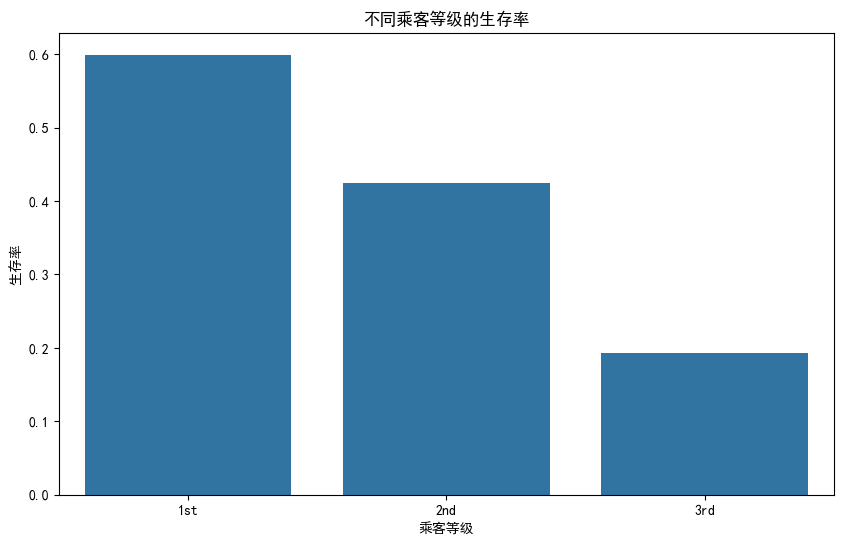


不同性别的生存率：
sex
female    0.663067
male      0.167059
Name: survived, dtype: float64


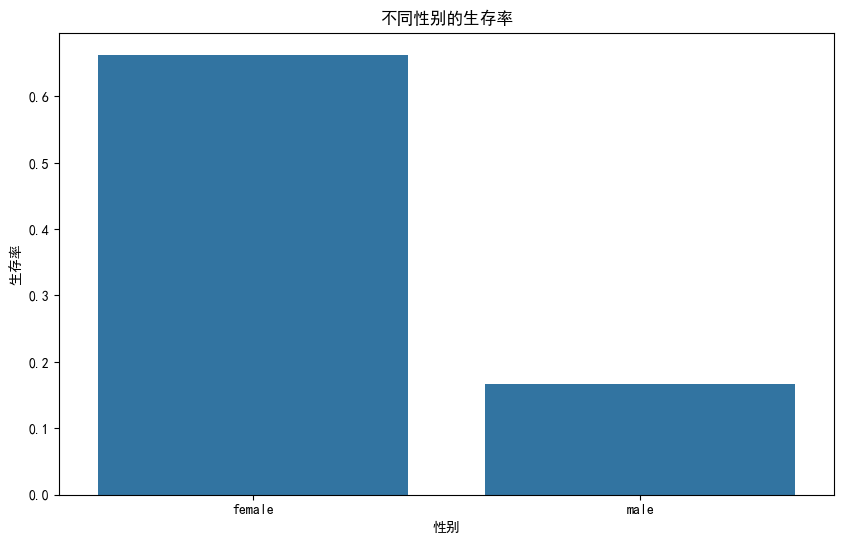


不同年龄组的生存率：
age_group
(0, 10]     0.702128
(10, 20]    0.469388
(20, 30]    0.355330
(30, 40]    0.283951
(40, 50]    0.451613
(50, 60]    0.510638
(60, 70]    0.222222
(70, 80]    0.000000
Name: survived, dtype: float64


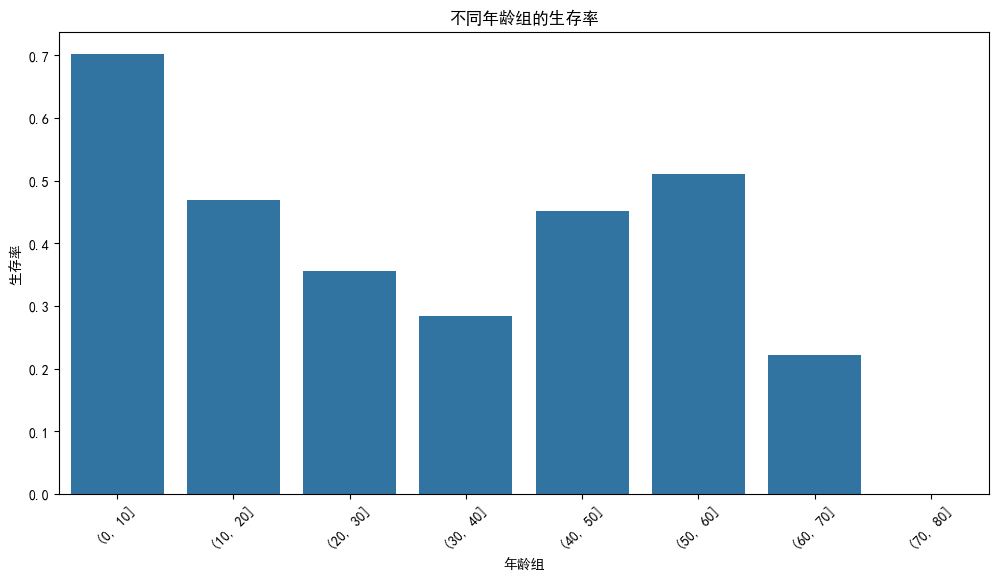


男性和女性的数量统计：
男性的数量：850，女性的数量：463


In [1]:
# 泰坦尼克号生存分析：EDA 可视化 + 决策树建模前的数据准备
import pandas as pd  # 数据处理
import numpy as np  # 数值计算
import matplotlib.pyplot as plt  # 基础绘图
import seaborn as sns  # 统计可视化；barplot/heatmap 等高层接口

titanic_data = pd.read_csv('data/titanic.txt')  # 读取泰坦尼克号数据；含 pclass/age/sex/survived 等列

print("泰坦尼克号数据集前5行：")  # 打印标题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 禁用 unicode 负号
print(titanic_data.head())  # 打印前 5 行；返回 DataFrame

titanic_subset = titanic_data[['pclass', 'age', 'sex', 'survived']].copy()  # 只取4列并深拷贝，避免 SettingWithCopyWarning

print("\n各列缺失值数量：")  # 打印标题
print(titanic_subset.isnull().sum())  # 返回 Series；索引=列名，值=缺失数

titanic_subset['age'] = titanic_subset['age'].fillna(titanic_subset['age'].mean())  # 用年龄均值填充 NaN；返回 Series

print("\n不同乘客等级的生存率：")  # 打印标题
pclass_survival = titanic_subset.groupby('pclass')['survived'].mean()  # 按舱位分组后对 survived 列求均值；返回 Series
print(pclass_survival)  # 打印各舱位生存率

plt.figure(figsize=(10, 6))  # 创建图窗
sns.barplot(x=pclass_survival.index, y=pclass_survival.values)  # 柱状图；x=舱位，y=生存率
plt.title('不同乘客等级的生存率')  # 图标题
plt.xlabel('乘客等级')  # x轴标签
plt.ylabel('生存率')  # y轴标签
plt.show()  # 渲染图像

print("\n不同性别的生存率：")  # 打印标题
sex_survival = titanic_subset.groupby('sex')['survived'].mean()  # 按性别分组求生存均值；返回 Series
print(sex_survival)  # 打印男女生存率

plt.figure(figsize=(10, 6))  # 创建图窗
sns.barplot(x=sex_survival.index, y=sex_survival.values)  # 性别生存率柱状图
plt.title('不同性别的生存率')  # 图标题
plt.xlabel('性别')  # x轴标签
plt.ylabel('生存率')  # y轴标签
plt.show()  # 渲染图像

age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]  # 年龄分箱边界列表；定义9个年龄区间
titanic_subset['age_group'] = pd.cut(titanic_subset['age'], bins=age_bins)  # 将连续年龄离散化为区间；返回 Categorical

print("\n不同年龄组的生存率：")  # 打印标题
age_survival = titanic_subset.groupby('age_group')['survived'].mean()  # 按年龄组分组求生存均值
print(age_survival)  # 打印各年龄组生存率

plt.figure(figsize=(12, 6))  # 创建较宽图窗以容纳多个年龄组
sns.barplot(x=age_survival.index.astype(str), y=age_survival.values)  # 区间对象转 str 后作 x 轴
plt.title('不同年龄组的生存率')  # 图标题
plt.xlabel('年龄组')  # x轴标签
plt.ylabel('生存率')  # y轴标签
plt.xticks(rotation=45)  # 旋转 x 轴标签 45° 防重叠
plt.show()  # 渲染图像

from sklearn.tree import DecisionTreeClassifier  # 决策树分类器
from sklearn.model_selection import train_test_split  # 数据划分
from sklearn.metrics import accuracy_score, classification_report  # 评估指标
from sklearn.tree import plot_tree  # 决策树可视化函数

print("\n男性和女性的数量统计：")  # 打印标题
sex_counts = titanic_subset['sex'].value_counts()  # 统计各性别人数；返回 Series，降序
print(f'男性的数量：{sex_counts["male"]}，女性的数量：{sex_counts["female"]}')  # 打印人数

titanic_subset['sex'] = titanic_subset['sex'].map({'male': 0, 'female': 1})  # 性别字符串→整数；0=男，1=女

if 'age_group' in titanic_subset.columns:  # 检查是否存在 age_group 列（避免重复运行报错）
    titanic_subset = titanic_subset.drop('age_group', axis=1)  # axis=1 按列删除；建模不需要分箱列

titanic_clean = titanic_subset.dropna()  # 删除任何仍含缺失的行；返回新 DataFrame


### 4.2 决策树模型构建与分类预测

> 基于清洗后的泰坦尼克号数据，使用  构建分类模型，并通过分位数、特征分桶等方式预测乘客是否生还。


X_train中男性和女性的数量统计：
男性的数量：663，女性的数量：321

决策树模型准确率：0.8389

分类报告：


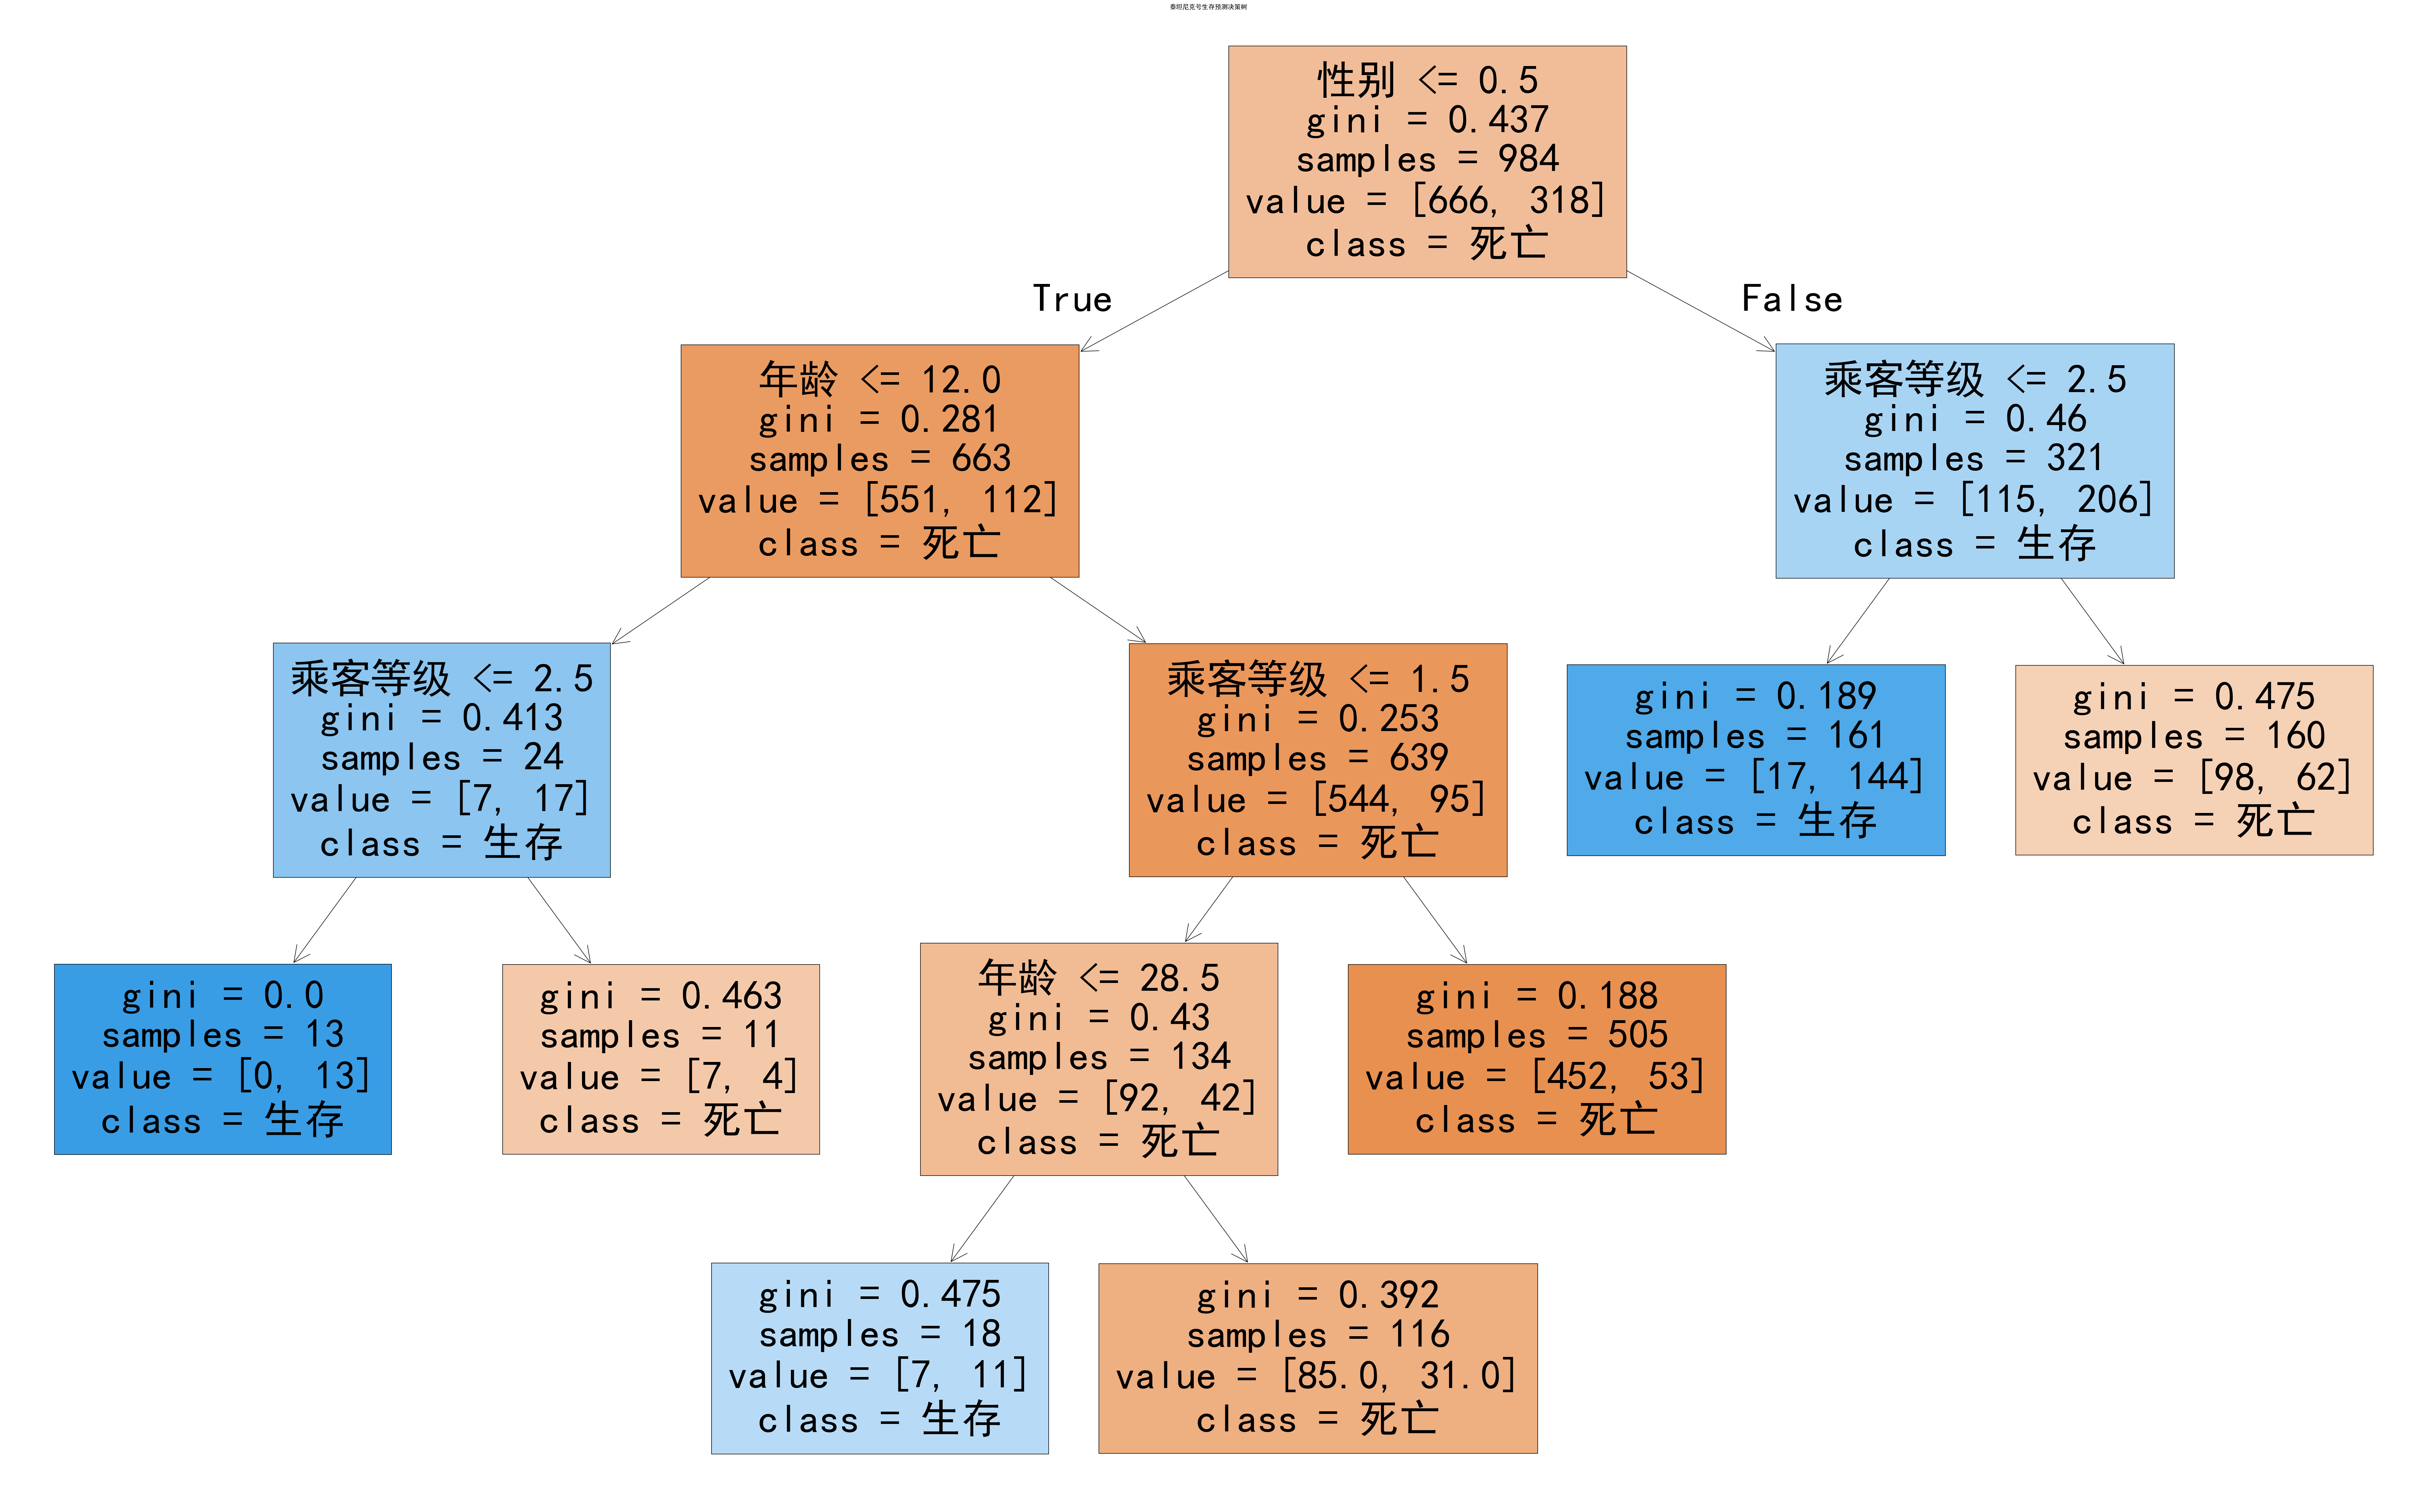


特征重要性：
       特征       重要性
2     sex  0.568333
0  pclass  0.324847
1     age  0.106820


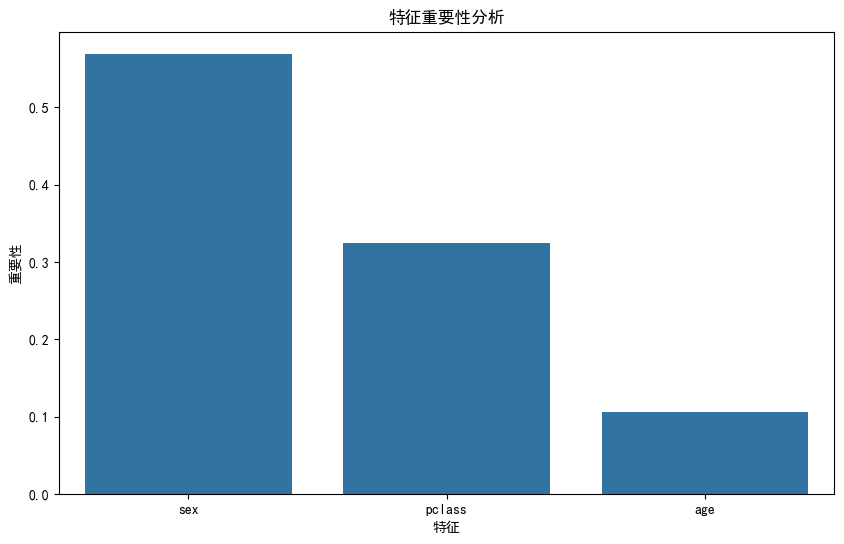


结论：
1. 乘客等级(pclass)：较高等级的乘客(如一等舱)生存率明显高于低等级
2. 性别(sex)：女性生存率显著高于男性，体现了'女士优先'的救生原则
3. 年龄(age)：儿童的生存率相对较高，而中年和老年人的生存率较低
4. 根据特征重要性分析，性别是影响生存最重要的因素，其次是乘客等级和年龄


In [ ]:
# 决策树建模：用舱位、年龄、性别预测是否生存

X = titanic_clean.copy()  # 深拷贝，避免修改原数据
X['pclass'] = X['pclass'].map({'1st': 1, '2nd': 2, '3rd': 3})  # 将文本舱位映射为有序整数；1=一等舱
X = X[['pclass', 'age', 'sex']]  # 仅保留 3 个特征列；返回 DataFrame
y = titanic_clean['survived']  # 标签列；0=未生存，1=生存；类型 Series

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)  # 75% 训练，25% 测试

# min_impurity_decrease：每次分裂要求不纯度至少下降该值，防止生成过深过拟合的树
# 初始化决策树分类器
# 常用超参数举例：
# - criterion: "gini"（默认，用于分类）或 "entropy"，用于选择分裂时的指标
# - max_depth: 树最大深度，防止过拟合，如 max_depth=5
# - min_samples_split: 每个内部节点划分所需最小样本数，如 min_samples_split=2
# - min_samples_leaf: 叶节点最少样本数，如 min_samples_leaf=1
# - min_impurity_decrease: 分裂所需最小不纯度减少量，调节树复杂度
# - random_state: 随机种子，确保结果可复现
dt_model = DecisionTreeClassifier(
    min_impurity_decrease=0.003,  # 分裂时最小不纯度减少，防止过拟合
    # criterion="gini",           # 默认基尼系数
    # max_depth=None,             # 可设定最大深度
    # min_samples_split=2,        # 节点最少样本数（默认2）
    # min_samples_leaf=1,         # 叶节点最少样本数（默认1）
    # random_state=42             # 固定随机种子保证可复现
)
dt_model.fit(X_train, y_train)  # 递归构建决策树；返回已拟合的模型

print("\nX_train中男性和女性的数量统计：")  # 打印标题
sex_counts_train = X_train['sex'].value_counts()  # 统计训练集中男(0)/女(1)的人数
print(f'男性的数量：{sex_counts_train[0]}，女性的数量：{sex_counts_train[1]}')  # 打印人数

y_pred = dt_model.predict(X_test)  # 对测试集预测 0/1 标签；返回 ndarray
accuracy = accuracy_score(y_test, y_pred)  # 计算测试集准确率；返回 float
print(f"\n决策树模型准确率：{accuracy:.4f}")  # 打印准确率
print("\n分类报告：")  # 打印标题（分类报告由后续代码生成，此处仅作提示）

plt.figure(figsize=(80, 50), dpi=120)  # 创建超大画布以容纳完整决策树
plot_tree(dt_model, filled=True, feature_names=['乘客等级', '年龄', '性别'], class_names=['死亡', '生存'])  # 可视化决策树；filled=True按类别着色
plt.title('泰坦尼克号生存预测决策树')  # 图标题
plt.show()  # 渲染图像

feature_importance = pd.DataFrame({  # 构建特征重要性 DataFrame
    '特征': X.columns,  # 特征名列表；类型 Index
    '重要性': dt_model.feature_importances_  # ndarray；各特征基于不纯度减少的归一化重要性，求和=1
})  # 右括号
feature_importance = feature_importance.sort_values('重要性', ascending=False)  # 按重要性降序排列
print("\n特征重要性：")  # 打印标题
print(feature_importance)  # 打印特征重要性表格

plt.figure(figsize=(10, 6))  # 创建图窗
sns.barplot(x='特征', y='重要性', data=feature_importance)  # 特征重要性柱状图
plt.title('特征重要性分析')  # 图标题
plt.show()  # 渲染图像

print("\n结论：")  # 打印结论标题
print("1. 乘客等级(pclass)：较高等级的乘客(如一等舱)生存率明显高于低等级")  # 结论1
print("2. 性别(sex)：女性生存率显著高于男性，体现了'女士优先'的救生原则")  # 结论2
print("3. 年龄(age)：儿童的生存率相对较高，而中年和老年人的生存率较低")  # 结论3
print("4. 根据特征重要性分析，性别是影响生存最重要的因素，其次是乘客等级和年龄")  # 结论4


## 五、随机森林（Random Forest）

> 随机森林是基于 Bagging 思想的集成学习算法，通过构建多棵决策树并投票决策，显著降低方差、提升泛化能力。


随机森林模型准确率：0.8571

随机森林特征重要性：
       特征       重要性
2     sex  0.484898
0  pclass  0.298198
1     age  0.216904


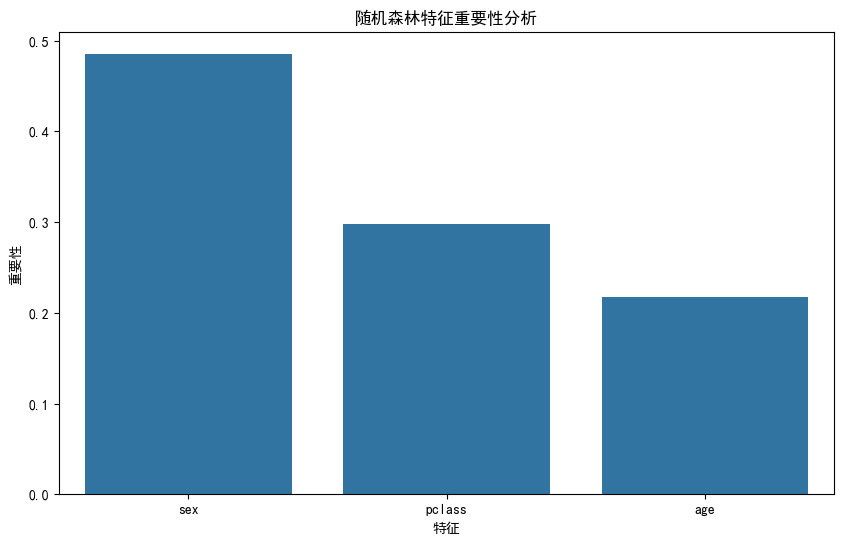


决策树与随机森林比较：
决策树准确率：0.8389
随机森林准确率：0.8571
准确率提升：1.82%


In [ ]:
# 随机森林：多棵决策树 Bagging 集成，通过降低方差提升泛化能力
from sklearn.ensemble import RandomForestClassifier  # 随机森林；内部自动 Bagging+随机特征
from sklearn.metrics import classification_report, confusion_matrix  # 评估指标

# 初始化随机森林分类器，设置常用超参数
# n_estimators: 森林中树的数量（默认100），越多越稳定但计算更慢
# max_depth: 每棵树的最大深度，防止过拟合（如None表示无限制）
# random_state: 随机种子，结果可复现
# bootstrap: 是否有放回采样（True表示有助于Bagging思想）
# max_samples: 每棵树随机采样子集的最大样本数（仅bootstrap=True时有效，可以是整数或0-1之间的比例，设为None表示全部样本），可进一步提升模型多样性，减少过拟合
# 常见重要超参数还有：
#   min_samples_split（内部结点再划分最小样本数, 默认2）
#   min_samples_leaf（叶子节点最小样本数, 默认1）
#   max_features（每棵树划分节点时，候选特征子集的最大数目，默认为"auto"）
#     - "auto"（等价于"sqrt"）：每次分裂节点时，随机选择特征总数的平方根个特征（适用于分类问题，默认推荐选项）
#     - "sqrt"：同上，提升树间差异性与模型泛化能力
#     - "log2"：每次分裂节点时，随机选择特征总数的对数（底为2），进一步提升树多样性
#     - 整数（如2、3）：每次仅从指定数量的特征中挑选最佳分裂特征，如设为2，则分裂时仅在2个特征中选择
#     - 小数（0~1之间，float）：指定比例，每次随机选择（max_features × 特征总数，向下取整）个特征。例如0.5即每次仅用一半特征作为候选，适合高维冗余特征场景
#     - None：采用所有特征进行节点分裂（高维时易过拟合，一般不建议）
#     - 影响分析：max_features 越小，森林中不同树的多样性越大，模型泛化能力增强，过拟合风险降低（但单棵树判别能力变弱）；反之则可能使模型单一、易过拟合
#     - 实践建议：高维、冗余特征情形建议用较小max_features（如"sqrt"、"log2"、或小数），特征数很少时可酌情增大，需防止过拟合
#   oob_score（是否使用包外样本估计泛化精度, 默认False）
rf_model = RandomForestClassifier(
    n_estimators=500,           # 森林中树的总数
    max_depth=3,                # 每棵树最大深度
    random_state=42,            # 固定随机种子
    bootstrap=True              # 是否有放回采样
)

rf_model.fit(X_train, y_train)  # 训练 500 棵决策树；每棵树用不同的 bootstrap 样本和随机特征子集

rf_pred = rf_model.predict(X_test)  # 多数投票预测；返回 ndarray

rf_accuracy = accuracy_score(y_test, rf_pred)  # 计算随机森林准确率；返回 float
print(f"\n随机森林模型准确率：{rf_accuracy:.4f}")  # 打印准确率

rf_feature_importance = pd.DataFrame({  # 构建特征重要性 DataFrame
    '特征': X.columns,  # 特征名；类型 Index
    '重要性': rf_model.feature_importances_  # 多棵树平均后的特征重要性；ndarray，求和=1
})  # 右括号
rf_feature_importance = rf_feature_importance.sort_values('重要性', ascending=False)  # 降序排列
print("\n随机森林特征重要性：")  # 打印标题
print(rf_feature_importance)  # 打印特征重要性表格

plt.figure(figsize=(10, 6))  # 创建图窗
sns.barplot(x='特征', y='重要性', data=rf_feature_importance)  # 特征重要性柱状图
plt.title('随机森林特征重要性分析')  # 图标题
plt.show()  # 渲染图像

print("\n决策树与随机森林比较：")  # 打印比较标题
print(f"决策树准确率：{accuracy:.4f}")  # 打印单棵决策树准确率（依赖上一 cell 的变量）
print(f"随机森林准确率：{rf_accuracy:.4f}")  # 打印随机森林准确率
print(f"准确率提升：{(rf_accuracy-accuracy)*100:.2f}%")  # 计算提升百分点


### 5.1 随机森林超参数调优（GridSearchCV）

> 使用  对随机森林的 （树的数量）和 （树的最大深度）进行网格搜索与交叉验证，找到最优超参数组合。

Fitting 7 folds for each of 25 candidates, totalling 175 fits

最佳超参数组合: {'max_depth': 2, 'n_estimators': 300}
最佳交叉验证得分: 0.8150
最佳随机森林模型在测试集上的准确率: 0.8511

优化前随机森林准确率: 0.8571
优化后随机森林准确率: 0.8511
准确率提升: -0.61%


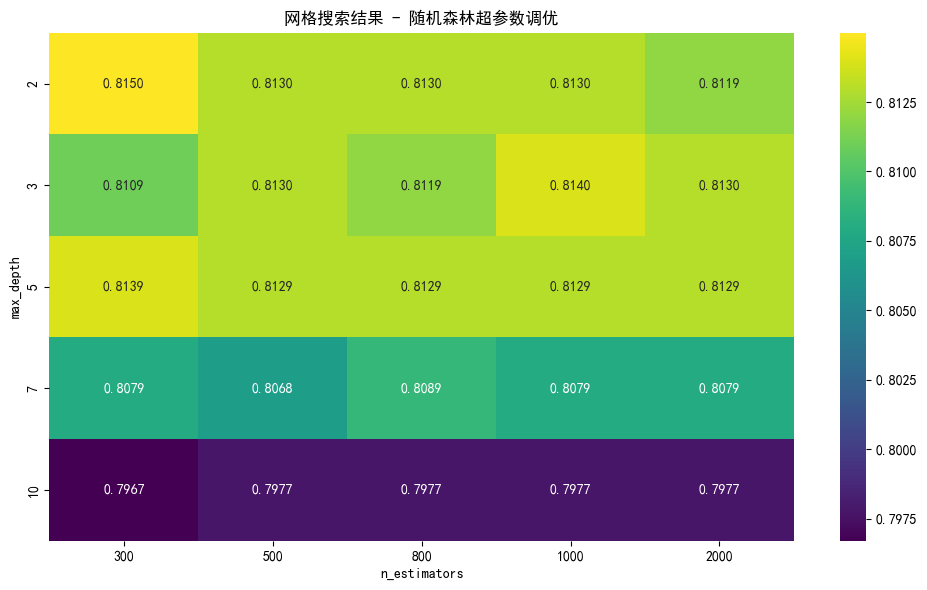

In [ ]:
# 随机森林 GridSearchCV：网格搜索 n_estimators（树棵数）与 max_depth（最大深度）
from sklearn.model_selection import GridSearchCV  # 网格搜索工具

param_grid = {  # 超参数候选字典
    'n_estimators': [300, 500, 800, 1000, 2000],  # 5 个树棵数候选值
    'max_depth': [2, 3, 5, 7, 10]  # 5 个最大深度候选值；共 5×5=25 种组合
}  # 右括号

rf = RandomForestClassifier(random_state=1)  # 基随机森林估计器；超参由网格覆盖

grid_search = GridSearchCV(  # 创建网格搜索对象
    estimator=rf,  # 被调参的模型
    param_grid=param_grid,  # 参数网格
    cv=7,  # 7 折交叉验证；每组参数训练 7 次
    scoring='accuracy',  # 评价指标
    n_jobs=-1,  # 使用全部 CPU 核心并行
    verbose=1  # verbose=1 打印每折进度；verbose=2 更详细
)  # 右括号

grid_search.fit(X_train, y_train)  # 在训练集上运行 25×7=175 次拟合；时间较长

print(f"\n最佳超参数组合: {grid_search.best_params_}")  # dict；最优 n_estimators 和 max_depth
print(f"最佳交叉验证得分: {grid_search.best_score_:.4f}")  # float；最优组合的 CV 平均准确率

best_rf_model = grid_search.best_estimator_  # 已在全训练集上 refit 的最优随机森林模型

best_rf_pred = best_rf_model.predict(X_test)  # 用最优模型预测测试集；返回 ndarray
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)  # 计算测试集准确率
print(f"最佳随机森林模型在测试集上的准确率: {best_rf_accuracy:.4f}")  # 打印结果

print(f"\n优化前随机森林准确率: {rf_accuracy:.4f}")  # 打印调参前准确率
print(f"优化后随机森林准确率: {best_rf_accuracy:.4f}")  # 打印调参后准确率
print(f"准确率提升: {(best_rf_accuracy-rf_accuracy)*100:.2f}%")  # 打印提升百分点

results = pd.DataFrame(grid_search.cv_results_)  # 将网格搜索结果转为 DataFrame；含每组参数的 mean_test_score 等
pivot_table = results.pivot_table(  # 构造透视表；行=max_depth，列=n_estimators，值=CV准确率
    values='mean_test_score',  # 取 CV 平均得分
    index='param_max_depth',  # 行索引：最大深度
    columns='param_n_estimators'  # 列索引：树棵数
)  # 右括号

plt.figure(figsize=(10, 6))  # 创建图窗
# 绘制超参数网格搜索结果的热力图
# pivot_table：行为max_depth，列为n_estimators，格内为每组参数下的交叉验证平均准确率
# annot=True 表示在每个格子里显示得分数值，cmap='viridis' 设置配色方案，fmt='.4f' 保留4位小数
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.4f')
plt.title('网格搜索结果 - 随机森林超参数调优')  # 图标题
plt.xlabel('n_estimators')  # x轴：树棵数
plt.ylabel('max_depth')  # y轴：最大深度
plt.tight_layout()  # 自动调整布局
plt.show()  # 渲染图像
